# Исследовательский анализ данных сервиса Яндекс Афиша


Дата: 15.02.2026

# Цель и задачи

Проведение анализ данных сервиса Яндекс Афиша с 1 июня по 30 октября 2024 года:
- выявление причин, из-за которых осенью 2024 года произошло увеличение количества заказов, при снижении средней стоимости заказа;
- выявление событий, площадок и организаторов, которые являются лидерами по привлечению аудитории;
- проверка гипотезы, что пользователи мобильных устройств активнее покупают билеты, чем пользователи ПК.

# Описание данных

Для анализа представлены три датасета: 
- `final_tickets_orders_df.csv` — данные обо всех заказах билетов, совершённых с разных типов устройств;
- `final_tickets_events_df.csv` — информация о событиях, включая город, регион, организаторов и площадки;
- `final_tickets_tenge_df.csv` — данные о курсе тенге к российскому рублю.

Описание датасета `final_tickets_orders_df.csv`:

- order_id — уникальный идентификатор заказа
- user_id — уникальный идентификатор пользователя
- created_dt_msk — дата создания заказа
- created_ts_msk — дата и время создания заказа
- event_id — идентификатор мероприятия
- cinema_circuit — сеть кинотеатров
- age_limit — возрастное ограничение мероприятия
- currency_code — валюта оплаты (rub, kzt)
- device_type_canonical — тип устройства (mobile, desktop)
- revenue — выручка от заказа
- service_name — билетный оператор
- tickets_count — количество купленных билетов
- total — общая сумма заказа
- days_since_prev — количество дней с предыдущей покупки пользователя

Описание датасета `final_tickets_events_df.csv`
- event_id — уникальный идентификатор мероприятия
- event_name — название мероприятия
- event_type_description — описание типа мероприятия
- event_type_main — основной тип мероприятия
- organizers — организаторы мероприятия
- region_name — регион проведения
- city_name — город проведения
- venue_id — идентификатор площадки
- venue_name — название площадки
- venue_address — адрес площадки

Описание датасета `final_tickets_tenge_df.csv`
- nominal — номинал(100 тенге)
- data — дата
- curs — курс тенге к рублю
- cdx — обозначение валюты(kzt)

# Оглавление

1. Загрузка данных
2. Предобработка данных и подготовка их к исследованию
3. Исследовательский анализ данных
4. Статистический анализ данных
5. Общий вывод и рекомендации

## Загрузка данных


Для анализа будем использовать библиотеки 
- pandas для работы с таблицами
- matplotlib и seaborn для визуализаций 
- numpy и scipy для последующих расчётов и статистических тестов

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
import plotly.graph_objs as go
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.express as px

In [2]:
# Загружаем датасеты
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
df_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

Познакомимся с данными датасета `df_orders`

In [3]:
# Просмотрим первые 5 строк df_orders
df_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
# Выведем общую информация о df_orders
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

**<p style="color: black; background-color: orange;">Вывод по `df_orders`</p>**

- Датасет содержит 290 849 строк и 14 столбцов с информацией обо всех заказах билетов, совершённых с мобильных и стационарных устройств.
- Пропуски присутствуют в столбце `days_since_prev` — это ожидаемо, так как для пользователей с первой покупкой интервал не определяется.
- Названия столбцов уже приведены к формату snake_case.

- дата и время создания заказа `created_dt_msk` и `created_ts_msk` имеют тип object, для работы со временем будет удобнее преобразовать в формат datetime64.
- выручка  `revenue`, количество купленных билетов `tickets_count`, количество дней с предыдущей покупки пользователя `total, days_since_prev` имеют типы данных: float64 и int64
- тип устройства `device_type_canonical`,  валюта оплаты `currency_code`, билетный оператор `service_name`, сеть кинотеатров `cinema_circuit` представлены в виде строк (object), что соответствует их содержимому.
- Признаки `revenue` и `total` указаны в разных валютах (RUB и KZT). Приведем все значения к единой валюте — рублям.
- Признак `device_type_canonical` содержит значения mobile и desktop, что позволит сегментировать пользователей по типу устройства.
- Для данных с типом int64 и float64 возможно снизить расрядность для экономии ресурсов системы.

Познакомимся с данными датасета `df_events`

In [5]:
# Просмотрим первые 5 строк df_events
df_events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
# Выведем общую информация о df_events
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


**<p style="color: black; background-color: orange;">Вывод по `df_events`</p>**

- Датасет содержит 22 427 строк и 11 столбцов с информацией о мероприятиях, организаторах и площадках проведения.
- Формат данных корректен, все поля заполнены — пропусков в таблице нет.
- Названия столбцов уже приведены к удобному формату snake_case.

- основной тип мероприятия `event_type_main`,  описание типа мероприятия `event_type_description`, регион проведения `region_name`, город проведения `city_name`, название площадки `venue_name`, адрес площадки `venue_address`, организаторы мероприятия `organizers` имеют тип object, что полностью подходит для работы с текстовыми данными;
- идентификаторы: мероприятия `event_id`, городf `city_id`, площадки `venue_id` имеют числовой тип int64.
- регион проведения `region_name` и город проведения `city_name` имеют тип object и содержат географическую информацию, пригодную для регионального анализа популярности событий.
- Для данных с типом int64 и float64 возможно снизить расрядность для экономии ресурсов системы.



Теперь изучим третий датасет — `df_tenge`

In [7]:
# Просмотрим первые 5 строк df_events
df_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
# Выведем общую информация о df_events
df_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


**<p style="color: black; background-color: orange;">Вывод по `df_tenge`</p>**
- Датасет содержит 357 строк и 4 столбца с ежедневной информацией о курсе казахстанского тенге к российскому рублю за 2024 год.
- Пропусков в таблице нет.
- Названия столбцов уже приведены к удобному формату snake_case.

- `data` — тип object, необходимо преобразовать в datetime64 для корректного объединения по дате
- номинал(100 тенге) `nominal` — имеет формат int64, всегда равен 100
- `curs` — курс тенге к рублю, тип float64
- `cdx` — обозначение валюты, тип object
- Для данных с типом int64 и float64 возможно снизить расрядность для экономии ресурсов системы.

## Предобработка данных и подготовка их к исследованию


In [9]:
# создадим запись с информацией об исходном количество строк в датасете df_orders
input_data=len(df_orders)

### Преобразуем типы данных

In [10]:
# Преобразуем в тип данных datetime64 для df_orders
df_orders['created_dt_msk'] = pd.to_datetime(df_orders['created_dt_msk'])
df_orders['created_ts_msk'] = pd.to_datetime(df_orders['created_ts_msk'])

# Преобразуем в тип данных datetime64 для df_tenge
df_tenge['data'] = pd.to_datetime(df_tenge['data'])

In [11]:
# понижаем разрядность для df_orders
for column in ['order_id', 'event_id', 'age_limit', 'tickets_count']:
    df_orders[column] = pd.to_numeric(df_orders[column], downcast = 'integer')

for column in ['revenue', 'total', 'days_since_prev']:
    df_orders[column] = pd.to_numeric(df_orders[column], downcast = 'float')

In [12]:
# понижаем разрядность для df_events
for column in ['event_id', 'city_id', 'venue_id']:
    df_events[column] = pd.to_numeric(df_events[column], downcast = 'integer')

In [13]:
# понижаем разрядность для df_tenge
df_tenge['nominal'] = pd.to_numeric(df_tenge['nominal'], downcast = 'integer')
df_tenge['curs'] = pd.to_numeric(df_tenge['curs'], downcast = 'float')

### Изучение пропусков


При знакомстве с данными было выявлено, что пропуски есть только в датафрейме `df_orders` в `days_since_prev`(количество дней с предыдущей покупки пользователя). Это нормально, так как для пользователей с первой покупкой интервал не определяется. Узнаем абсолютное и относительное количество пропусков в этом столбце.

In [14]:
# Применяем метод isna() 
df_orders['days_since_prev'].isna().sum()
# Подсчитываем долю строк с пропусками
gap=df_orders['days_since_prev'].isna().mean().round(3)*100

print(f"Пропуски в столбце days_since_prev составляют: {gap}%")


Пропуски в столбце days_since_prev составляют: 7.5%


Результаты показывают, что пропуски в столбце `days_since_prev` составляют примерно 7,5% строк. Это логично, так как для пользователей с первой покупкой интервал до предыдущего заказа не может быть рассчитан.



### Проверяем наличие явных и неявных дубликатов


In [15]:
for column in df_orders.columns:
    duplicates_count = df_orders[df_orders[column].duplicated()].shape[0]
    print(f"Количество дубликатов в колонке {column}: {duplicates_count}")

Количество дубликатов в колонке order_id: 0
Количество дубликатов в колонке user_id: 268909
Количество дубликатов в колонке created_dt_msk: 290696
Количество дубликатов в колонке created_ts_msk: 9863
Количество дубликатов в колонке event_id: 268403
Количество дубликатов в колонке cinema_circuit: 290843
Количество дубликатов в колонке age_limit: 290844
Количество дубликатов в колонке currency_code: 290847
Количество дубликатов в колонке device_type_canonical: 290847
Количество дубликатов в колонке revenue: 248321
Количество дубликатов в колонке service_name: 290813
Количество дубликатов в колонке tickets_count: 290827
Количество дубликатов в колонке total: 235376
Количество дубликатов в колонке days_since_prev: 290699


В `order_id` дубликаты отсутствуют. В остальных данных дубликаты допустимы.

In [16]:
# Проверим неявные дубликаты без учёта order_id
dubl = df_orders.drop(columns=['order_id']).duplicated().sum()

print(f"Найдено {dubl} неявных дубликатов")


Найдено 30 неявных дубликатов


In [17]:
# Посмотрим первые 10 строк дубликатов
dubles = df_orders.drop(columns=['order_id']).duplicated(keep=False)
df_orders.loc[dubles].sort_values(by='created_ts_msk').head(10)


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
232676,7927528,c7a762e320f0def,2024-06-19,2024-06-19 11:07:59,538926,нет,18,rub,mobile,0.000000,Билеты без проблем,3,0.000000,0.0
232673,1585808,c7a762e320f0def,2024-06-19,2024-06-19 11:07:59,538926,нет,18,rub,mobile,0.000000,Билеты без проблем,3,0.000000,0.0
285618,8548070,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:50,489843,нет,18,rub,desktop,989.570007,Билеты без проблем,3,10995.230469,0.0
285617,8548041,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:50,489843,нет,18,rub,desktop,989.570007,Билеты без проблем,3,10995.230469,0.0
285622,8547867,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.430054,Билеты без проблем,4,14660.309570,0.0
285615,8548012,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.430054,Билеты без проблем,4,14660.309570,0.0
285614,8547983,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.430054,Билеты без проблем,4,14660.309570,0.0
285612,8547809,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.570007,Билеты без проблем,3,10995.230469,0.0
285619,8548099,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.570007,Билеты без проблем,3,10995.230469,0.0
176438,8248268,8f95286aa5fd8d7,2024-06-20,2024-06-20 10:57:19,244875,нет,0,rub,mobile,15.730000,Лови билет!,3,524.390015,0.0


Часть записей содержат информацию об одинаковой дате, времени и сумме заказа, что очень похоже на техническую ошибку. Удалим дублируемые данные.

In [18]:
df_orders = df_orders.drop_duplicates(subset=['user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 
                                             'cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 
                                             'revenue', 'service_name', 'tickets_count', 'total', 'days_since_prev'], 
                                     keep=False)


In [19]:
for column in df_events.columns:
    duplicates_count = df_events[df_events[column].duplicated()].shape[0]
    print(f"Количество дубликатов в колонке {column}: {duplicates_count}")

Количество дубликатов в колонке event_id: 0
Количество дубликатов в колонке event_name: 7179
Количество дубликатов в колонке event_type_description: 22407
Количество дубликатов в колонке event_type_main: 22420
Количество дубликатов в колонке organizers: 18134
Количество дубликатов в колонке region_name: 22346
Количество дубликатов в колонке city_name: 22075
Количество дубликатов в колонке city_id: 22074
Количество дубликатов в колонке venue_id: 19202
Количество дубликатов в колонке venue_name: 19210
Количество дубликатов в колонке venue_address: 19202


В `event_id` дубликаты отсутствуют. В остальных данных дубликаты допустимы.

In [20]:
# Проверим неявные дубликаты без учёта event_id
dubl = df_events.drop(columns=['event_id']).duplicated().sum()

print(f"Найдено {dubl} неявных дубликатов")


Найдено 871 неявных дубликатов


In [21]:
# Посмотрим первые 10 строк дубликатов
dubles = df_events.drop(columns=['event_id']).duplicated(keep=False)
df_events.loc[dubles].sort_values(by='venue_id').head(10)


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
21713,582361,7f52ef6e-0dd7-4b97-8798-adf047efb226,концерт,концерты,№2459,Каменевский регион,Глиногорск,213,898,"Школа композиции ""Протон"" Лтд","ул. Водопроводная, д. 99 к. 1"
16708,553216,7f52ef6e-0dd7-4b97-8798-adf047efb226,концерт,концерты,№2459,Каменевский регион,Глиногорск,213,898,"Школа композиции ""Протон"" Лтд","ул. Водопроводная, д. 99 к. 1"
17632,557658,38b5dc2c-7502-4733-b258-d6d463c3ae06,концерт,концерты,№3065,Каменевский регион,Глиногорск,213,898,"Школа композиции ""Протон"" Лтд","ул. Водопроводная, д. 99 к. 1"
19457,566978,9ef62275-0d9d-44ac-8e58-951303d09971,концерт,концерты,№836,Каменевский регион,Глиногорск,213,898,"Школа композиции ""Протон"" Лтд","ул. Водопроводная, д. 99 к. 1"
10617,516611,38b5dc2c-7502-4733-b258-d6d463c3ae06,концерт,концерты,№3065,Каменевский регион,Глиногорск,213,898,"Школа композиции ""Протон"" Лтд","ул. Водопроводная, д. 99 к. 1"
11383,524001,b1e44172-e242-4706-b519-da0b57b8cd9b,событие,другое,№3060,Каменевский регион,Глиногорск,213,898,"Школа композиции ""Протон"" Лтд","ул. Водопроводная, д. 99 к. 1"
11722,526988,9ef62275-0d9d-44ac-8e58-951303d09971,концерт,концерты,№836,Каменевский регион,Глиногорск,213,898,"Школа композиции ""Протон"" Лтд","ул. Водопроводная, д. 99 к. 1"
17653,557751,b1e44172-e242-4706-b519-da0b57b8cd9b,событие,другое,№3060,Каменевский регион,Глиногорск,213,898,"Школа композиции ""Протон"" Лтд","ул. Водопроводная, д. 99 к. 1"
20749,575883,1738ad7f-2fb6-4aca-8215-7dd9ea768042,концерт,концерты,№836,Каменевский регион,Глиногорск,213,898,"Школа композиции ""Протон"" Лтд","ул. Водопроводная, д. 99 к. 1"
17631,557657,1738ad7f-2fb6-4aca-8215-7dd9ea768042,концерт,концерты,№836,Каменевский регион,Глиногорск,213,898,"Школа композиции ""Протон"" Лтд","ул. Водопроводная, д. 99 к. 1"


Найдено 871 дубликатов записях по таблице `df_events`. Возможно организаторы концертов, на которые продаются билеты, сами вносит информацию и таким образом записи дублируются с разными `event_id`. Но для наших целей это никак не ухудшает качество данных и в данном случае эти дуюликаты допустимы.

In [22]:
# Проверим уникальные значения в df_tenge
for column in df_tenge.columns:
    duplicates_count = df_tenge[df_tenge[column].duplicated()].shape[0]
    print(f"Количество дубликатов в колонке {column}: {duplicates_count}")

Количество дубликатов в колонке data: 0
Количество дубликатов в колонке nominal: 356
Количество дубликатов в колонке curs: 109
Количество дубликатов в колонке cdx: 356


В колонке `data` дубликаты отсутствуют. В остальных колонках данных дубликаты допустимы.

### Объединим датасеты `df_orders`, `df_events` и `df_tenge`

In [23]:
# Объединяем заказы df_orders с таблицей событий df_events
df_one = df_orders.merge(df_events, on = 'event_id', how = 'left')

In [24]:
# Оценим пропуски у объединенного датасета
missing_values = df_one.isna().sum()
missing_percent = (missing_values / len(df_one)) * 100

result = pd.DataFrame({
    'Количество пропусков': missing_values,
    'Процент пропусков, %': missing_percent.round(2)
})

# Показываем данные только для столбцов с пропусками
result[result['Количество пропусков'] > 0]

,Количество пропусков,"Процент пропусков, %"
days_since_prev,21940,7.54
event_name,238,0.08
event_type_description,238,0.08
event_type_main,238,0.08
organizers,238,0.08
region_name,238,0.08
city_name,238,0.08
city_id,238,0.08
venue_id,238,0.08
venue_name,238,0.08


Если делать объединение методом `left`, то для 0,08% заказов из `df_orders` нет описания мероприятия из таблицы `df_events`. Так как пропусков совсем немного, то объединим методом `inner`, исключив пропуски.

In [25]:
# Объединяем заказы df_orders с таблицей событий df_events
df_one = df_orders.merge(df_events, on = 'event_id', how = 'inner')

In [26]:
# Объединяем данные с df_tenge
df_all = pd.merge(df_one, df_tenge, left_on='created_dt_msk', right_on='data', how='left')

**Создадим несколько новых столбцов:**
-	`revenue_rub` — приведем выручку с заказа к единой валюте — российскому рублю. Для этого используем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю.
-	`one_ticket_revenue_rub` — рассчитаем выручку с продажи одного билета на мероприятие.
-	`month` — выделим месяц оформления заказа в отдельный столбец.
-	`season` — создадим столбец с информацией о сезонности, включая такие категории, как: `лето`, `осень`, `зима`, `весна`.


In [27]:
# приведем выручку с заказа к единой валюте
def convert_kzt_to_rub(row):
    if row['currency_code'] == 'kzt':
        return row['revenue'] * row['curs'] / row['nominal']
    else:
        return row['revenue']

df_all['revenue_rub'] = df_all.apply(convert_kzt_to_rub, axis=1)

In [28]:
# рассчитаем выручку с продажи одного билета
df_all['one_ticket_revenue_rub'] = df_all['revenue_rub'] / df_all['tickets_count']

In [29]:
# выделим месяц оформления заказа в отдельный столбец.
df_all['month'] = df_all['created_dt_msk'].dt.month

# создадим столбец с информацией о сезонности
season_dict = {1:'зима',2: 'зима', 3: 'весна', 4: 'весна', 5:'весна', 6: 'лето',7: 'лето', 8: 'лето',9: 'осень',10: 'осень', 11: 'осень', 12: 'зима'}
df_all['season'] = df_all['month'].map(season_dict)

# понижаем разрядность у созданных колонок
df_all['month'] = pd.to_numeric(df_all['month'], downcast = 'integer')
df_all['revenue_rub'] = pd.to_numeric(df_all['revenue_rub'], downcast = 'float')
df_all['one_ticket_revenue_rub'] = pd.to_numeric(df_all['one_ticket_revenue_rub'], downcast = 'float')

In [30]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290553 entries, 0 to 290552
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290553 non-null  int32         
 1   user_id                 290553 non-null  object        
 2   created_dt_msk          290553 non-null  datetime64[ns]
 3   created_ts_msk          290553 non-null  datetime64[ns]
 4   event_id                290553 non-null  int32         
 5   cinema_circuit          290553 non-null  object        
 6   age_limit               290553 non-null  int8          
 7   currency_code           290553 non-null  object        
 8   device_type_canonical   290553 non-null  object        
 9   revenue                 290553 non-null  float32       
 10  service_name            290553 non-null  object        
 11  tickets_count           290553 non-null  int8          
 12  total                   290553

### Изучение значений в ключевых столбцах

#### Для категориальных значений 

- Изучим, какие категории присутствуют в данных. 
- Проверим, встречаются ли значения, которые могут обозначать пропуски в данных или отсутствие информации. 
- Проведем нормализацию данных.

In [31]:
# Проверим уникальные значения в df_orders
# Список колонок, в которых нужно подсчитать дубликаты
columns_check = ['cinema_circuit', 
                'age_limit', 
                'currency_code', 
                'device_type_canonical', 
                'service_name', 
                'event_type_description', 
                'event_type_main',  
                'region_name',
                'city_name',
                'venue_name',
                'venue_address']

# Подсчитываем значений для каждой колонки из списка, отсортируем по алфавиту
for column in columns_check:
    check = df_all[column].value_counts().sort_index(ascending=True)
    unique_count = df_all[column].nunique()
    
    print(f"Уникальные значения в {column}:")
    print(check)
    print(f"Всего уникальных значений: {unique_count}")
    print("\n")

Уникальные значения в cinema_circuit:
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
нет           289155
Name: cinema_circuit, dtype: int64
Всего уникальных значений: 6


Уникальные значения в age_limit:
0     61467
6     52148
12    62464
16    78552
18    35922
Name: age_limit, dtype: int64
Всего уникальных значений: 5


Уникальные значения в currency_code:
kzt      5069
rub    285484
Name: currency_code, dtype: int64
Всего уникальных значений: 2


Уникальные значения в device_type_canonical:
desktop     58104
mobile     232449
Name: device_type_canonical, dtype: int64
Всего уникальных значений: 2


Уникальные значения в service_name:
Crazy ticket!               790
Show_ticket                2200
Билет по телефону            85
Билеты без проблем        63495
Билеты в интернете            4
Билеты в руки             40333
Быстробилет                2001
Быстрый кассир              381
Весь в билетах            16849
Восьмёрк

- В столбце `cinema_circuit` есть информация о 4 сетях кинотеатров: КиноСити, Киномакс, Москино, ЦентрФильм. Есть 1 261 записей о том, что кинотеатр входит в киносеть без указания ее названия и еще  289 155 записей с пометкой "нет", что может обозначать пропуски в данных или отсутствие информации.
- В `age_limit` есть информация о возрастном ограничении: 0+, 6+, 12+, 16+ и 18+ лет.
- В `currency_code` есть сведения только о двух валютах, применяемых для расчета: рубли и тенге.
- В `device_type_canonical` указана информация о типе устройства, с которого был оформлен заказ. В данных есть информация о desktop и mobile.
- В `service_name` присутствует информация о 36 операторах, которые продают билеты.
- В `event_type_main` есть информация о 7 типах мероприятий.
- В `event_type_description` присутствует информация об описании 20 типов мероприятий.
- В `region_name` информация о 81 одном регионе. 
- В `city_name` информация о 352 городах.
- В `venue_address` информация о 3 225 адресах площадок
- Приведем  данные в колонках `service_name`, `region_name`, `city_name` и `venue_address` к нижнему регистру и исключим лишние пробелы    

In [32]:
#Приведем тектосвые данные к нижнему регистру и исключим лишние пробелы
df_all['service_name'] = df_all['service_name'].str.lower().str.strip()
df_all['region_name'] = df_all['region_name'].str.lower().str.strip()
df_all['city_name'] = df_all['city_name'].str.lower().str.strip()
df_all['venue_address'] = df_all['venue_address'].str.lower().str.strip()

#### Для количественных значений 

- Изучим распределение и наличие выбросов

Для анализа выберем ключевые числовые показатели — выручка от заказа `revenue_rub` и количество купленных билетов`tickets_count`. На предыдущем этапе мы привели расчеты из тенге в рубли, поэтому сравнивать будем все в рублях.
Скорее всего данные для разных валют будет отличаться, поэтому изучим распределение выручка от заказа в разрезе валюты (рубли и тенге) `currency_code`.

In [33]:
# для заказов в рублях
df_all[df_all['currency_code'] == 'rub'][['revenue_rub', 'tickets_count', 'total', 'age_limit']].describe().round(1)

,revenue_rub,tickets_count,total,age_limit
count,285484.0,285484.0,285484.0,285484.0
mean,548.1,2.8,6331.1,10.2
std,871.8,1.2,8619.9,6.5
min,-90.8,1.0,-358.9,0.0
25%,114.2,2.0,2120.4,6.0
50%,346.7,3.0,4674.6,12.0
75%,793.3,4.0,8783.2,16.0
max,81174.5,57.0,811745.4,18.0


In [34]:
# для заказов в тенге
df_all[df_all['currency_code'] == 'kzt'][['revenue_rub', 'tickets_count', 'total', 'age_limit']].describe().round(1)

,revenue_rub,tickets_count,total,age_limit
count,5069.0,5069.0,5069.0,5069.0
mean,981.3,2.8,75237.0,11.5
std,975.2,1.1,68039.2,4.8
min,0.0,1.0,0.0,0.0
25%,98.8,2.0,9353.7,6.0
50%,734.7,3.0,61647.2,12.0
75%,1419.6,4.0,114868.8,16.0
max,5256.8,6.0,344606.5,18.0


- Заказы в рублях преобладают.
- Для рублевых заказов есть отрицательные значения выручки. Вероятно это возвраты билетов и для дальнейшего анализа такие данные стоит удалить
- Средняя выручка по заказам в рублях составляет 548.1, при медиане 346.7, что говорит о сильной асимметрии распределения и наличии выбросов — максимальные значения превышают 81 174.5.
- В заказах, оплаченных в тенге, средняя выручка составляет 981.3, при медиане 734.7, разброс значений также значительный, но выбросы менее выражены.
- В обоих случаях количество билетов стабильно — медианное значение 3, что свидетельствует о типичном размере заказа.
- Возрастое ограничение для мероприятий примерно схожи - 10.2 и 11.5.

In [35]:
# исключим отрицательную выручку
df_all = df_all[df_all['revenue_rub'] >= 0].reset_index()

Далее визуализируем распределения, чтобы убедиться в наличии выбросов и форме распределения данных.

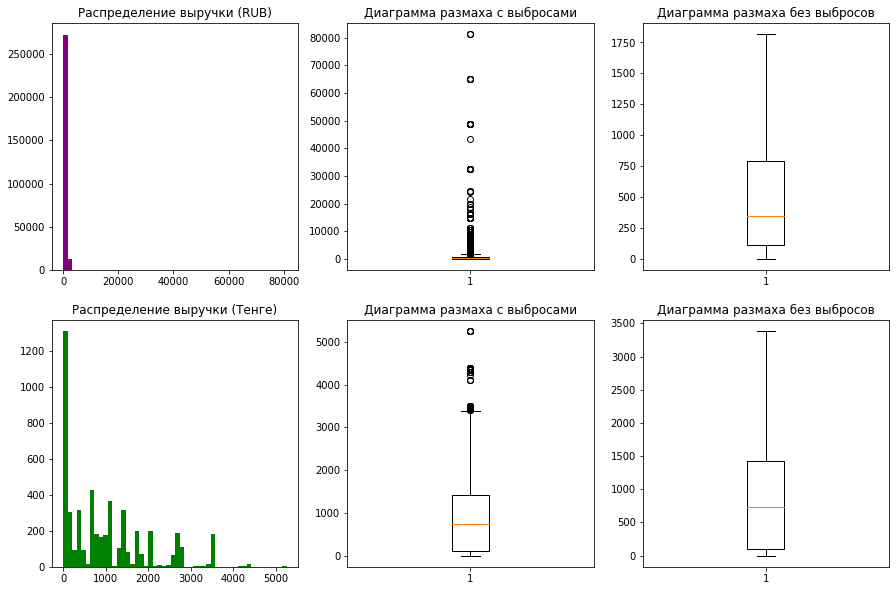

In [36]:
rub_df = df_all[df_all['currency_code'] == 'rub']
kzt_df = df_all[df_all['currency_code'] == 'kzt']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# График для RUB
axes[0, 0].hist(rub_df['revenue_rub'], bins=50, color='purple')
axes[0, 0].set_title('Распределение выручки (RUB)')

# Диаграмма размаха для RUB с выбросами
axes[0, 1].boxplot(rub_df['revenue_rub'])
axes[0, 1].set_title('Диаграмма размаха с выбросами')

# Диаграмма размаха для RUB без выбросов
axes[0, 2].boxplot(rub_df['revenue_rub'], sym='')
axes[0, 2].set_title('Диаграмма размаха без выбросов')

# График для KZT
axes[1, 0].hist(kzt_df['revenue_rub'], bins=50, color='green')
axes[1, 0].set_title('Распределение выручки (Тенге)')

# Диаграмма размаха для KZT с выбросами
axes[1, 1].boxplot(kzt_df['revenue_rub'])
axes[1, 1].set_title('Диаграмма размаха с выбросами')

# Диаграмма размаха для KZT без выбросов
axes[1, 2].boxplot(kzt_df['revenue_rub'], sym='')
axes[1, 2].set_title('Диаграмма размаха без выбросов')

plt.show()

- Распределение выручки в рублях резко скошено влево — подавляющее большинство заказов имеет выручку до 150 - 750, встречаются выбросы от 10 000 до 80 000.
- Диаграмма размаха показывает множество точек-аномалий, расположенных за пределами межквартильного диапазона.
- Распределение в тенге также несимметрично, но «хвост» менее длинный. Основная масса заказов сосредоточена в диапазоне 150–1500, при медиане около 750. Выбросы присутствуют и здесь, но в меньшем количестве и величине.
- Обе валютные группы содержат аномальные значения выручки, особенно в рублях.
- Перед расчётом средних показателей отберем значения по 99-му процентилю и удалим отрицательные значения для корректного анализа.

In [37]:
# фильтруем данные для каждой валюты
kzt_filtred = kzt_df['revenue_rub'].quantile(0.99)
rub_filtred = rub_df['revenue_rub'].quantile(0.99)

kzt_limited = kzt_df[kzt_df['revenue_rub'] <= kzt_filtred]
rub_limited = rub_df[rub_df['revenue_rub'] <= rub_filtred]

# Теперь объединяем отфильтрованные данные в один датасет
df_all = pd.concat([kzt_limited, rub_limited], ignore_index=True)

Повторно посмотри на характер распределения данных после фильтрации по по 99-му процентилю:

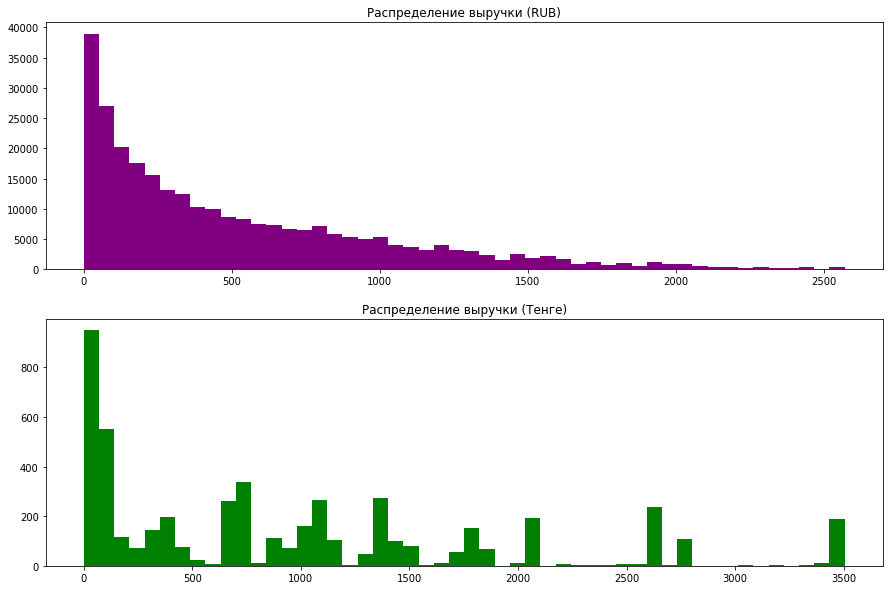

In [38]:
rub_df = df_all[df_all['currency_code'] == 'rub']
kzt_df = df_all[df_all['currency_code'] == 'kzt']

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# График для RUB
axes[0].hist(rub_df['revenue_rub'], bins=50, color='purple')
axes[0].set_title('Распределение выручки (RUB)')

# График для KZT
axes[1].hist(kzt_df['revenue_rub'], bins=50, color='green')
axes[1].set_title('Распределение выручки (Тенге)')

plt.show()

Теперь посмотрим на характер распределения количества покупаемых билетов:

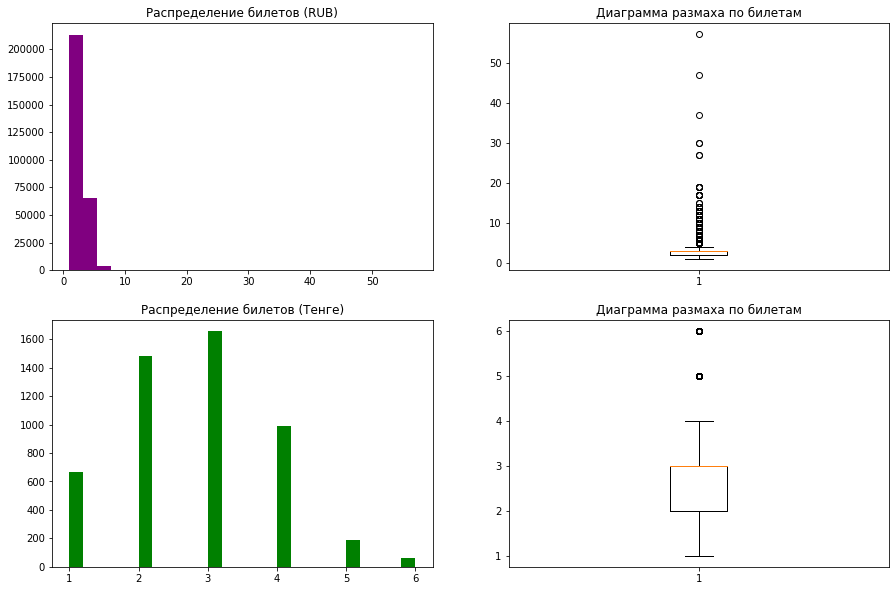

In [39]:
rub_df = df_all[df_all['currency_code'] == 'rub']
kzt_df = df_all[df_all['currency_code'] == 'kzt']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# График для RUB
axes[0, 0].hist(rub_df['tickets_count'], bins=25, color='purple')
axes[0, 0].set_title('Распределение билетов (RUB)')

# Диаграмма размаха для RUB с выбросами
axes[0, 1].boxplot(rub_df['tickets_count'])
axes[0, 1].set_title('Диаграмма размаха по билетам')


# График для KZT
axes[1, 0].hist(kzt_df['tickets_count'], bins=25, color='green')
axes[1, 0].set_title('Распределение билетов (Тенге)')

# Диаграмма размаха для KZT с выбросами
axes[1, 1].boxplot(kzt_df['tickets_count'])
axes[1, 1].set_title('Диаграмма размаха по билетам')


plt.show()

In [40]:
# подсчитаем сколько данных было исключено из исходного датасета
share =  round ((input_data - len(df_all))/input_data*100,2)
print(f'Количество данных, которое было исключено: {share}%, что составляет {input_data - len(df_all)} записей.')
print(f'Количество данных, оставшихся после предобработки: {len(df_all)} записей.')

Количество данных, которое было исключено: 1.21%, что составляет 3506 записей.
Количество данных, оставшихся после предобработки: 287343 записей.


**<p style="color: black; background-color: orange;">Вывод:</p>**

- Данные, содержащие время и дату были преобразованы из типа object в datetime64;
- Понижана разрядность для всех данных с типом int64 и float64
- Были найдены пропуски в `days_since_prev`, что составило 7,5% от всех данных. 
- Дубликаты по `order_id` в датасете `df_orders` и `event_id` по `df_events` отсутствуют. В других данных дубликаты присутствуют и это допустимо.
- В датасете `df_orders` было найдено 30 дубликатов строчек.  Часть записей содержали информацию об одинаковой дате, времени и сумме заказа, что очень похоже на техническую ошибку. Эти дубликаты были удалены.
- Датасеты `df_orders`, `df_events` и `df_tenge` были обедены в общий датасет `df_all`.
- Были созданы новые столбцы: 
  - `revenue_rub` — приведена выручка с заказа к единой валюте — российскому рублю.
  - `one_ticket_revenue_rub` — рассчитна выручка с продажи одного билета на мероприятие.
  -	`month` — выделен месяц оформления заказа в отдельный столбец.
  -	`season` — создан столбец с информацией о сезонности.
- Данные в колонках `service_name`, `region_name`, `city_name` и `venue_address` были отнормированы и приведены к нижнему регистру, исключены лишние пробелы.
- Количество данных, которое было исключено: 1.21%, что составляет 3506 записей.



**Изучены значений в ключевых столбцах:**

**Для категориальных данных были изучены, какие категории присутствуют в данных. Проверены обозначения пропусков в данных и их отсутствие. Проведена нормализацию данных:**
- В столбце `cinema_circuit` есть информация о 4 сетях кинотеатров: КиноСити, Киномакс, Москино, ЦентрФильм. Есть 1 261 записей о том, что кинотеатр входит в киносеть без указания ее названия и еще 289 155 записей с пометкой "нет", что может обозначать пропуски в данных или отсутствие информации.
- В `age_limit` есть информация о возрастном ограничении: 0+, 6+, 12+, 16+ и 18+ лет.
- В `urrency_code` есть сведения только о двух валютах, применяемых для расчета: рубли и тенге.
- В `device_type_canonical` указана информация о типе устройства, с которого был оформлен заказ. В данных есть информация о `desktop` и `mobile`.
- В `service_name` присутствует информация о 36 операторах, которые продают билеты.
- В `vent_type_main` есть информация о 7 типах мероприятий.
- В `event_type_description` присутствует информация об описании 20 типов мероприятий.
- В `region_name` информация о 81 одном регионе.
- В `city_name` информация о 352 городах.
- В `venue_address` информация о 3 225 адресах площадок

**Для количественных данных было изучено распределение данных и наличие выбросов по выручке и количеству билетов. Использованы статистические показатели, гистограммы распределения значений и диаграммы размаха. Были отобраны выбросы и исключены по 99-му процентилю.**
- Заказы в рублях преобладают.
- Для рублевых заказов есть отрицательные значения выручки. Вероятно это возвраты билетов и для дальнейшего анализа такие данные были исключены.
- Средняя выручка по заказам в рублях составляет 548.1, при медиане 346.7, что говорит о сильной асимметрии распределения и наличии выбросов — максимальные значения превышают 81 174.5.
- В заказах, оплаченных в тенге, средняя выручка составляет 981.3, при медиане 734.7, разброс значений также значительный, но выбросы менее выражены.
- В обоих случаях количество билетов стабильно — медианное значение 3, что свидетельствует о типичном размере заказа.
- Возрастое ограничение для мероприятий примерно схожи - 10.2 и 11.5.
- Распределение выручки в рублях резко скошено влево — подавляющее большинство заказов имеет выручку до 150 - 750, встречаются выбросы от 10 000 до 80 000.
- Диаграмма размаха показывает множество точек-аномалий, расположенных за пределами межквартильного диапазона.
- Распределение в тенге также несимметрично, но «хвост» менее длинный. Основная масса заказов сосредоточена в диапазоне 150–1500, при медиане около 750. Выбросы присутствуют и здесь, но в меньшем количестве и величине.
- Обе валютные группы содержат аномальные значения выручки, особенно в рублях.
- Распределение покупаемых билетов в рублях скошено влево. Чаще покупают по 3-4 билета. Но встречаются выбрросы свыше 50 билетов.
- Распределение покупаемых билетов в тенге более симметрично и приближено к нормальному. Количество покупаемхы билетов варьируется от 1 до 6 штук.

## Исследовательский анализ данных


### Анализ распределения заказов по сегментам и их сезонные изменения

- Изучим изменение пользовательской активности и пользовательского интереса в связи с сезонностью. 
- Изучим распределение заказов по сегментам (тип мероприятия `event_type_main`, тип устройства `device_type_canonical`, категория мероприятий по возрастному рейтингу `age_limit`) и их сезонные изменения:
  - Для каждого месяца найдем количество заказов и визуализируем результаты. Проверим, фиксируется ли увеличение заказов от июня к ноябрю 2024 года.
  - Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу. Результаты визуализируем графиком.
  - Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью.

- Сделаем вывод, как меняется распределение заказов в каждой категории с наступлением осени. 
- Изучим, было ли изменение средней стоимости одного билета в разрезе разных типов мероприятий.


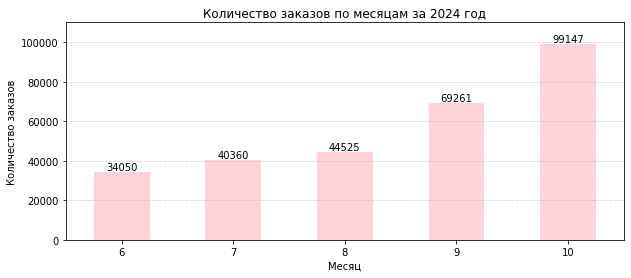

In [41]:
# Визуализируем динамику заказов по месяцам

# Рассчитаем количество заказов по месяцам
users_per_month = df_all.groupby('month')['order_id'].count()

plt.figure(figsize=(10, 4))

# Добавляем прозрачность и задаем цвет баров
users_per_month.plot(kind='bar', alpha=0.7, color='pink')

plt.title('Количество заказов по месяцам за 2024 год')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.xticks(rotation=0)  # поворачивает подписи на оси X

plt.ylim(0, 110000)

# Включаем сетку
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Добавляем значения на диаграмму
for i, v in enumerate(users_per_month):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

plt.show()


**График наглядно показывает, что с июня по октябрь количество заказов постепенно увеличивается. Но так как у нас нет данных за год, то невозможно точно сказать, что присутствует сезонность в поведении пользователей.**



Сравненим летний и осенний периоды по категориям мероприятий `season`.

In [42]:
# Фильтруем данные по сезонам и будем применять этот фильтр для всех анализов сезонности
df_summer = df_all[df_all['season'] == 'лето']
df_autumn = df_all[df_all['season'] == 'осень']

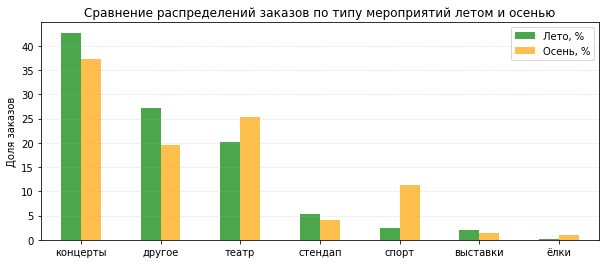

,"Лето, %","Осень, %"
концерты,42.7,37.3
другое,27.1,19.6
театр,20.1,25.4
стендап,5.3,4.1
спорт,2.5,11.2
выставки,2.0,1.4
ёлки,0.2,1.0


In [43]:
# Рассчитаем долю заказов по типу мероприятия
summer_events = df_summer['event_type_main'].value_counts(normalize=True)
autumn_events = df_autumn['event_type_main'].value_counts(normalize=True)

# Объединим летние и осенние доли в один датафрейм
season_event = pd.DataFrame({
    'Лето, %': summer_events*100,
    'Осень, %': autumn_events*100
}).fillna(0).round(1).sort_values(by = ['Лето, %', 'Осень, %'], ascending = False)



# Визуализируем сравнение распределений
season_event.plot(kind='bar', figsize=(10, 4), color=['green', 'orange'], alpha=0.7)

# Включаем сетку
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.title('Сравнение распределений заказов по типу мероприятий летом и осенью')
plt.xlabel('')
plt.ylabel('Доля заказов')
plt.xticks(rotation=0)
plt.show()


display(season_event)


**Анализ распределения заказов в летний и осенний периоды показывает различия:**
- Концерты лидируют по количеству заказов, однако их доля уменьшается с 41 % до 36 %.
- Наблюдается увеличение интереса к театральным постановкам: доля заказов возрастает с 20 % до 25 %, что свидетельствует о повышении популярности культурных мероприятий в холодное время года.
- Заметный рост отмечается в категории спортивных событий: с 2,6 % до 11,6 %.
- В то же время доля заказов в категориях «другое» и «стендап» уменьшилась.

Рассмотрим распределение заказов по типу устройства `device_type_canonical`:



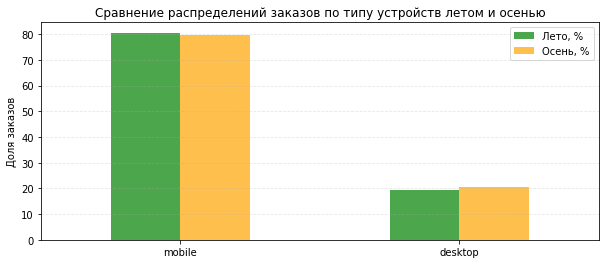

,"Лето, %","Осень, %"
mobile,80.6,79.6
desktop,19.4,20.4


In [44]:
# Рассчитаем долю заказов по типу устройства
summer_devices = df_summer['device_type_canonical'].value_counts(normalize=True)
autumn_devices = df_autumn['device_type_canonical'].value_counts(normalize=True)

# Объединим летние и осенние доли в один датафрейм
season_devices = pd.DataFrame({
    'Лето, %': summer_devices*100,
    'Осень, %': autumn_devices*100
}).fillna(0).round(1).sort_values(by = ['Лето, %', 'Осень, %'], ascending = False)

# Визуализируем сравнение распределений
season_devices.plot(kind='bar', figsize=(10, 4), color=['green', 'orange'], alpha=0.7)
# Включаем сетку
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.title('Сравнение распределений заказов по типу устройств летом и осенью')
plt.xlabel('')
plt.ylabel('Доля заказов')
plt.xticks(rotation=0)
plt.show()

display(season_devices)


**Анализ распределения заказов по типам устройств между летним и осенним периодами демонстрирует стабильность:**
- Мобильные устройства сохраняют доминирующую позицию, составляя примерно 80% от общего числа заказов.
- Доля заказов, оформленных с помощью стационарных устройств, немного увеличилась — с 19,3% до 20,2%.

Посмотрим на распределение заказов по возрастным категориям `age_limit`:



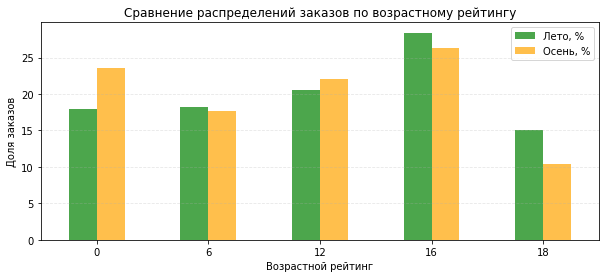

,"Лето, %","Осень, %"
0,17.9,23.6
6,18.2,17.6
12,20.5,22.1
16,28.4,26.3
18,15.0,10.4


In [45]:
# Рассчитаем долю заказов по возрастной группе
summer_age = df_summer['age_limit'].value_counts(normalize=True)
autumn_age = df_autumn['age_limit'].value_counts(normalize=True)

# Объединим летние и осенние доли в один датафрейм
season_age = pd.DataFrame({
    'Лето, %': summer_age*100,
    'Осень, %': autumn_age*100
}).fillna(0).round(1).sort_index()

# Визуализируем сравнение распределений
season_age.plot(kind='bar', figsize=(10, 4), color=['green', 'orange'], alpha=0.7)
# Включаем сетку
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.title('Сравнение распределений заказов по возрастному рейтингу')
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Доля заказов')
plt.xticks(rotation=0)
plt.show()

season_age

**Анализ распределения доли мероприятий по возрастным рейтингам показывает следующие тенденции:**
- Наблюдается увеличение доли мероприятий с рейтингом 0+ с 18% до 24%, что свидетельствует о росте интереса семейной аудитории.
- Категория мероприятий с рейтингом 12+ также демонстрирует небольшой рост — с 20% до 22%.
- Сегмент с рейтингом 16+ остаётся лидером по количеству заказов, однако его доля немного снизилась — с 29% до 26%.
- Доля мероприятий с рейтингом 18+ уменьшилась — с 15% до 10%.

Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью:

In [46]:
# Группировка и вычисление среднего значения
mean_revenue = df_all.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].mean().unstack()

# Вычисление процентной разницы
mean_revenue['изменение'] = ((mean_revenue['осень'] - mean_revenue['лето']) / mean_revenue['осень'])
mean_revenue = mean_revenue.sort_values(by='изменение', ascending=False)

# Функция для применения стилей к значениям
def color_filter(val):
    if val < 0:
        return 'color: red'
    elif val > 0:
        return 'color: green'
    else:
        return ''

# Применение стиля отображения
mean_revenue_style = mean_revenue.style.format({
    'лето': '{:.1f}',
    'осень': '{:.1f}',
    'изменение': '{:.1%}'
}).applymap(color_filter)


display(mean_revenue_style)


season,лето,осень,изменение
event_type_main,,,
выставки,86.8,91.9,5.6%
стендап,218.5,231.1,5.5%
спорт,50.8,50.0,-1.6%
другое,77.8,76.5,-1.8%
концерты,304.8,268.4,-13.6%
ёлки,271.4,229.6,-18.2%
театр,214.1,176.0,-21.7%


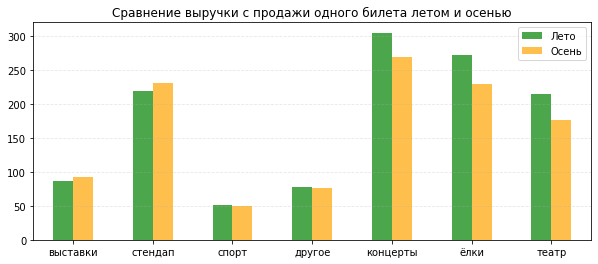

In [47]:

# Построение столбчатой диаграммы
mean_revenue[['лето', 'осень']].plot(kind='bar', figsize=(10, 4), color=['green', 'orange'], alpha=0.7)
# Включаем сетку
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.title('Сравнение выручки с продажи одного билета летом и осенью')
plt.xlabel('')
plt.ylabel('')
plt.legend(['Лето', 'Осень'])
plt.xticks(rotation=0)

plt.show()


**<p style="color: black; background-color: orange;">Вывод:</p>**
**Проведённый анализ выявил изменение структуры стоимости билетов:**
- стоимость билета снизилась для театров (-21.7%), ёлок (-18.2%) и концертов (-13.6%).
- для билетов за выставки и стендап произошел рост в среднем на 5.5%
- для спортивных мероприятий и другое цены на билеты почти не изменились.

С учетом, что осенью наблюдает рост количества заказов, а концерты являются самыми популярными мероприятиями (изменение количества покупаемых билетов осенью составило -5%), то можно сделать вывод, что изменение стоимости билетов для театров (-21.7%), ёлок (-18.2%) и концертов (-13.6%) может быть связано с сезонными акциями и скидками, для стимулирования продаж.

### Изучение активность пользователей осенью 2024 года

Проанализируем динамику изменений по дням для: 
- общего числа заказов;
- количества активных пользователей DAU;
- среднего числа заказов на одного пользователя;
- средней стоимости одного билета.


In [48]:
# отберем данные только за осенний период на основе df_autumn из прошлых вычислений

# Группируем данные по дате и пользователю, считаем количество заказов для каждого пользователя
orders_in_autumn = df_autumn.groupby(['created_dt_msk', 'user_id']).agg(
    user_orders=('order_id', 'count')).reset_index()

# Создаем сводную статистику по дням
# Группируем по дате, считаем общее количество заказов, уникальных пользователей и среднее количество заказов на пользователя
daily_stats = orders_in_autumn.groupby('created_dt_msk').agg(
    total_orders=('user_orders', 'sum'),  # Общее количество заказов за день
    DAU=('user_id', 'nunique'),  # Количество уникальных пользователей за день
    avg_orders_per_user=('user_orders', 'mean')    # Среднее количество заказов на пользователя за день
).reset_index()

# Считаем средней стоимости одного билета по дням
avg_ticket = df_autumn.groupby('created_dt_msk')['one_ticket_revenue_rub'].mean().reset_index()

# Объединяем все в одну таблицу
orders_in_autumn = daily_stats.merge(avg_ticket, on='created_dt_msk')
orders_in_autumn = orders_in_autumn.rename(columns={'one_ticket_revenue_rub': 'avg_one_ticket_revenue'})

display(orders_in_autumn)

,created_dt_msk,total_orders,DAU,avg_orders_per_user,avg_one_ticket_revenue
0,2024-09-01,1327,564,2.352837,200.168701
1,2024-09-02,1376,573,2.401396,190.015640
2,2024-09-03,5094,777,6.555985,80.650131
3,2024-09-04,1760,684,2.573099,179.363754
4,2024-09-05,1941,738,2.630081,189.804474
...,...,...,...,...,...
56,2024-10-27,2844,1032,2.755814,187.300186
57,2024-10-28,2836,985,2.879188,170.773666
58,2024-10-29,2832,998,2.837675,177.667923
59,2024-10-30,2924,1039,2.814244,182.977478


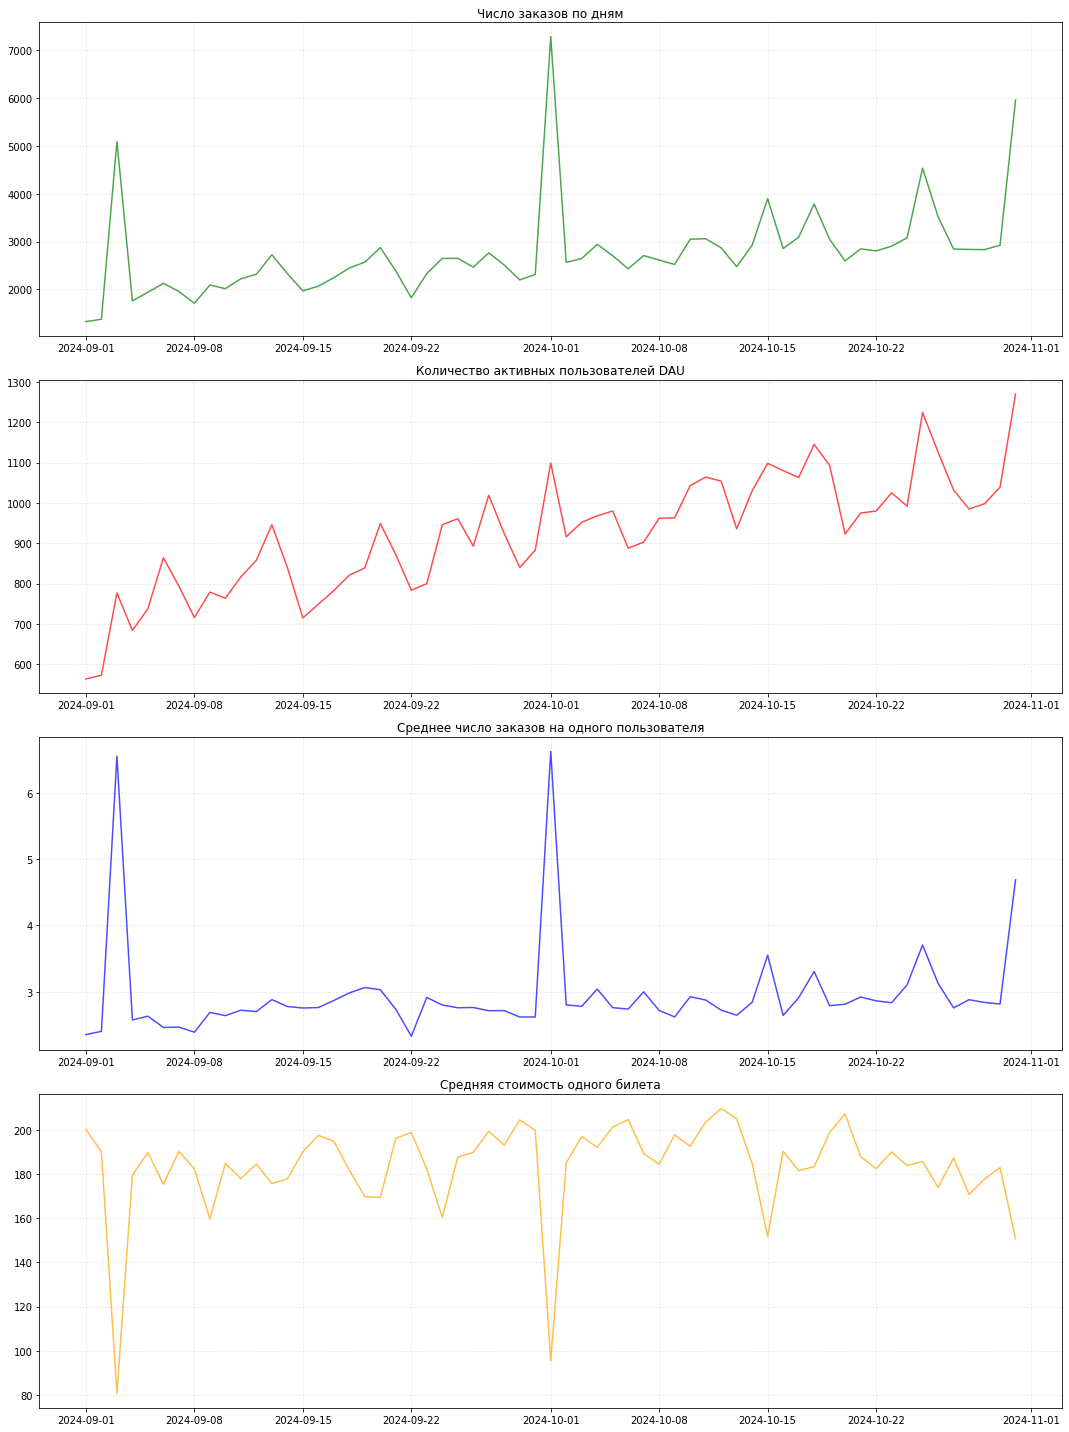

In [49]:
fig, axes = plt.subplots(nrows=4, figsize=(15, 20))  # задаем размер фигуры и количество графиков

# Строим график для total_orders
axes[0].plot(orders_in_autumn['created_dt_msk'], orders_in_autumn['total_orders'], color='green', alpha=0.7)
axes[0].set_title('Число заказов по дням')
axes[0].grid(axis='both', linestyle='--', alpha=0.3)  # включаем сетку для первого графика

# Строим график для DAU
axes[1].plot(orders_in_autumn['created_dt_msk'], orders_in_autumn['DAU'], color='red', alpha=0.7)
axes[1].set_title('Количество активных пользователей DAU')
axes[1].grid(axis='both', linestyle='--', alpha=0.3)  # включаем сетку для второго графика

# Строим график для avg_orders_per_user
axes[2].plot(orders_in_autumn['created_dt_msk'], orders_in_autumn['avg_orders_per_user'], color='blue', alpha=0.7)
axes[2].set_title('Среднее число заказов на одного пользователя')
axes[2].grid(axis='both', linestyle='--', alpha=0.3)  # включаем сетку для третьего графика

# Строим график для avg_one_ticket_revenue
axes[3].plot(orders_in_autumn['created_dt_msk'], orders_in_autumn['avg_one_ticket_revenue'], color='orange', alpha=0.7)
axes[3].set_title('Средняя стоимость одного билета')
axes[3].grid(axis='both', linestyle='--', alpha=0.3)  # включаем сетку для четвертого графика

plt.tight_layout()  # для лучшего расположения графиков
plt.show()  # показываем графики


- В осенний период наблюдаем увеличение активности пользователей, что проявляется в росте количества заказов и числа уникальных пользователей (DAU). 
- Заметные всплески активности приходятся на начало сентября и октября, что может быть связано с организацией крупных мероприятий,специальных акций или значительных покупках билетов по сниженным ценам или скидкам.
- В остальное время показатели остаются стабильными: пользователи в среднем совершали 2–3 заказа в день, а средняя стоимость билета варьировалась в пределах 160–200 рублей.

**Таким образом, можно сделать вывод, что активность пользователей осенью увеличивается, причём основной вклад в этот рост вносит повышение количества заказов по более низким ценам.**

Изучим недельную цикличность:



In [50]:
# Добавляем день недели
df_autumn = df_all[df_all['season'] == 'осень'].copy()
df_autumn['day_of_week'] = df_autumn['created_dt_msk'].dt.weekday+1

orders_in_autumn = df_autumn.groupby(['day_of_week', 'user_id']).agg(
    user_orders=('order_id', 'count')).reset_index()

In [51]:
# Создаем сводную статистику по дням
# Группируем по дате, считаем общее количество заказов, уникальных пользователей и среднее количество заказов на пользователя
daily_stats = orders_in_autumn.groupby('day_of_week').agg(
    total_orders=('user_orders', 'sum'),  # Общее количество заказов за день
    DAU=('user_id', 'nunique'),  # Количество уникальных пользователей за день
    avg_orders_per_user=('user_orders', 'mean')    # Среднее количество заказов на пользователя за день
).reset_index()

# Считаем средней стоимости одного билета по дням
avg_ticket = df_autumn.groupby('day_of_week')['one_ticket_revenue_rub'].mean().reset_index()

# Объединяем все в одну таблицу
orders_in_autumn = daily_stats.merge(avg_ticket, on='day_of_week')
orders_in_autumn = orders_in_autumn.rename(columns={'one_ticket_revenue_rub': 'avg_one_ticket_revenue'})

display(orders_in_autumn)

,day_of_week,total_orders,DAU,avg_orders_per_user,avg_one_ticket_revenue
0,1,21495,4443,4.837947,184.378571
1,2,31437,4792,6.560309,140.891479
2,3,22850,4814,4.746572,186.269562
3,4,27116,4964,5.462530,178.257736
4,5,24810,4869,5.095502,185.908340
5,6,21325,4570,4.666302,192.404068
6,7,19375,4393,4.410426,198.165070


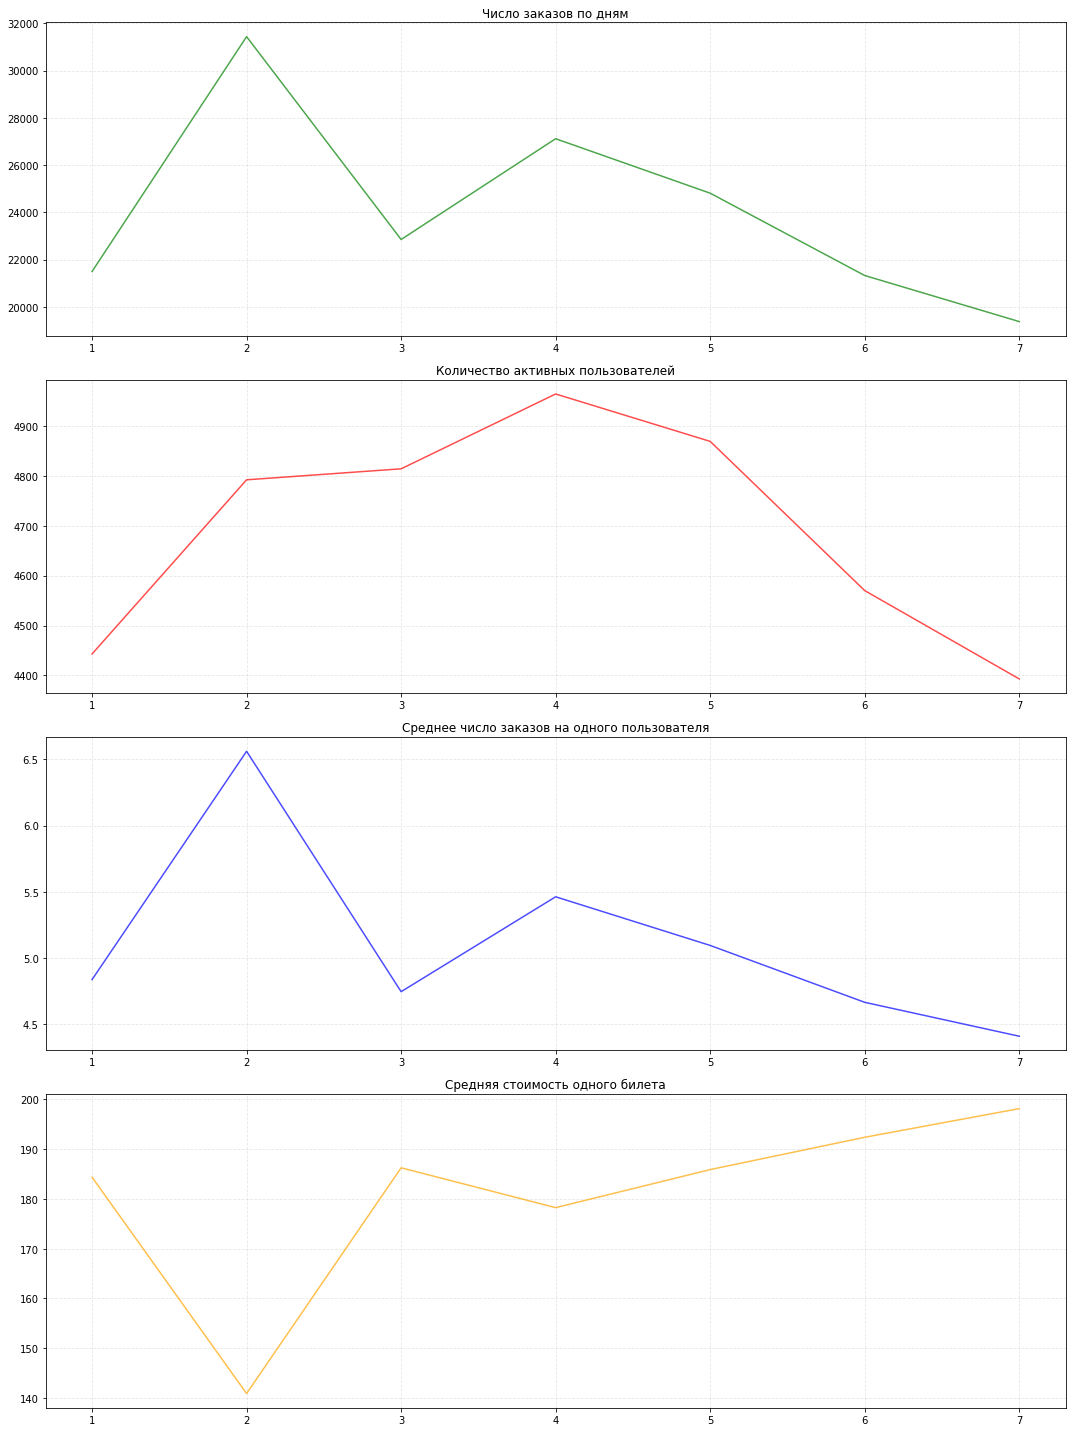

In [52]:
fig, axes = plt.subplots(nrows=4, figsize=(15, 20))  # задаем размер фигуры и количество графиков

# Строим график для total_orders
axes[0].plot(orders_in_autumn['day_of_week'], orders_in_autumn['total_orders'], color='green', alpha=0.7)
axes[0].set_title('Число заказов по дням')
axes[0].grid(axis='both', linestyle='--', alpha=0.3)  # включаем сетку для первого графика

# Строим график для DAU
axes[1].plot(orders_in_autumn['day_of_week'], orders_in_autumn['DAU'], color='red', alpha=0.7)
axes[1].set_title('Количество активных пользователей')
axes[1].grid(axis='both', linestyle='--', alpha=0.3)  # включаем сетку для второго графика

# Строим график для avg_orders_per_user
axes[2].plot(orders_in_autumn['day_of_week'], orders_in_autumn['avg_orders_per_user'], color='blue', alpha=0.7)
axes[2].set_title('Среднее число заказов на одного пользователя')
axes[2].grid(axis='both', linestyle='--', alpha=0.3)  # включаем сетку для третьего графика

# Строим график для avg_one_ticket_revenue
axes[3].plot(orders_in_autumn['day_of_week'], orders_in_autumn['avg_one_ticket_revenue'], color='orange', alpha=0.7)
axes[3].set_title('Средняя стоимость одного билета')
axes[3].grid(axis='both', linestyle='--', alpha=0.3)  # включаем сетку для четвертого графика

plt.tight_layout()  # для лучшего расположения графиков
plt.show()  # показываем графики


**Изучение недельной активности показывает:**
- рост числа заказов в начале недели и снижением к концу недели, как по общему числу заказов, так и на одного покупателя;
- рост числа уникалных пользователей в середине недели и спад активности к выхоным;
- рост стоимости одного билета к выходным и сильную просадку по цене по вторникам, что может говорить об акциях и скидках в этот день.

### Изучение популярных событий и партнёров

- Рассмотрим, как события распределены по регионам и партнёрам. 
* Выделим ключевые регионы и партнёры, которые вносят наибольший вклад в выручку.
- Ответим на вопрос, существуют ли явные лидеры среди регионов и партнёров.

#### Для каждого региона посчитаем уникальное количество мероприятий, общее число заказов и выручку

In [53]:
# Группируем по регионам
event_region = df_all.groupby('region_name').agg(
               unique_events=('event_id', 'nunique'),  
               total_orders=('order_id', 'count'),
                total_revenue = ('revenue_rub', 'sum')).reset_index()

# Сортируем по количеству мероприяти
event_region = event_region.sort_values('unique_events', ascending=False)

# Вычисляем общее количество уникальных событий и заказов
total_unique_events = df_all['event_id'].nunique()
total_orders = df_all['order_id'].count()
total_revenue = df_all['revenue_rub'].sum()

# Рассчитываем доли
event_region['unique_events_share'] = event_region['unique_events'] / total_unique_events*100
event_region['total_orders_share'] = event_region['total_orders'] / total_orders*100
event_region['total_revenue_share'] = event_region['total_revenue'] / total_revenue*100


event_region['unique_events_share'] = event_region['unique_events_share'].round(1)
event_region['total_orders_share'] = event_region['total_orders_share'].round(1)
event_region['total_revenue_share'] = event_region['total_revenue_share'].round(1)

# отсечем данные и оставим только данные по регионам, которые приносят больше 1% выручки
event_region = event_region.loc[event_region['total_revenue_share'] > 1].reset_index(drop=True)

display(event_region)

,region_name,unique_events,total_orders,total_revenue,unique_events_share,total_orders_share,total_revenue_share
0,каменевский регион,5935,89657,5.590603e+07,26.6,31.2,37.5
1,североярская область,3798,43720,2.210340e+07,17.0,15.2,14.8
2,широковская область,1225,16099,8.628149e+06,5.5,5.6,5.8
3,светополянский округ,1068,7486,3.039622e+06,4.8,2.6,2.0
4,речиновская область,701,6266,2.630316e+06,3.1,2.2,1.8
5,травяная область,683,5036,1.787822e+06,3.1,1.8,1.2
6,горицветская область,551,5153,1.697500e+06,2.5,1.8,1.1
7,серебринская область,541,5586,2.106600e+06,2.4,1.9,1.4
8,яблоневская область,534,6118,3.505188e+06,2.4,2.1,2.3
9,медовская область,503,13888,2.927312e+06,2.3,4.8,2.0


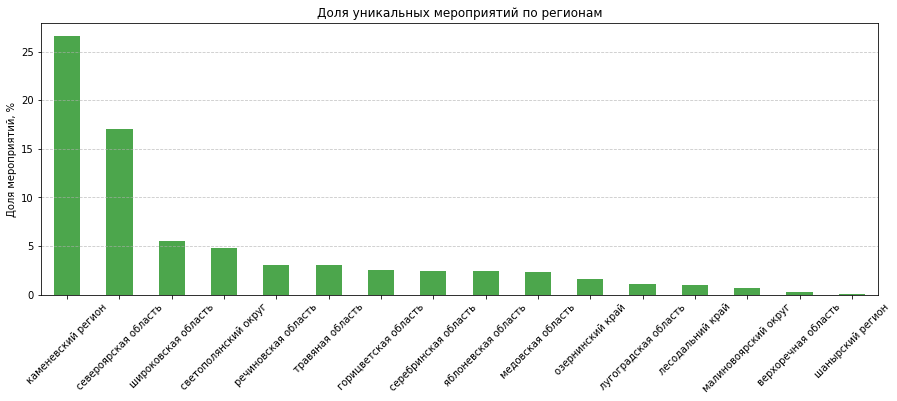

In [54]:
# Предполагаем, что event_region уже содержит необходимые данные
event_region.plot(kind='bar', 
                  x='region_name', 
                  y='unique_events_share', 
                  figsize=(15, 5), 
                  color=['green'], 
                  alpha=0.7, 
                  legend =False
)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.title('Доля уникальных мероприятий по регионам')
plt.xlabel('')
plt.ylabel('Доля мероприятий, %')

plt.xticks(rotation=45)  # Поворот названий регионов для лучшего отображения
plt.show()


In [55]:
# подсчитаем, какую совокупную долю имеют регионы с выручкой более 1% от общей

total_share_of_events = event_region['unique_events_share'].sum().round(1)
total_share_of_orders = event_region['total_orders_share'].sum().round(1)
total_share_of_revenue = event_region['total_revenue_share'].sum().round(1)


print(f'Совокупная доля регионов с выручкой более 1%:')
print(f'По количеству событий: {total_share_of_events}')
print(f'По количеству заказов: {total_share_of_orders}')
print(f'По сумме выручки: {total_share_of_revenue}')



Совокупная доля регионов с выручкой более 1%:
По количеству событий: 74.5
По количеству заказов: 79.3
По сумме выручки: 85.9000015258789


Анализ данных показывает:
- Каменевский регион занимает первое место по количеству уникальных мероприятий с результатом 5935 мероприятий. 
- В числе лидеров также Североярская область - 3798 мероприятий.
- Примерно на одном уровне Широковская область - 1225 и Светополянский округ - 1068
- Между первым и пятым местами наблюдается значительный разрыв в количестве проведённых мероприятий. Это может быть обусловлено различными факторами, включая социально-демографические особенности (например, более высокая численность населения или уровень развития региона).
- Из 81 региона участвующих в выборке, 16 регионов занимают 74.5% ко количеству событий, 79.3% ро количеству заказов и 85.9% по сумме выручки.

#### Для каждого билетного партнёра посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов

In [56]:
# Группируем по партнёрам
event_partner = df_all.groupby('service_name').agg(
                unique_events=('event_id', 'nunique'),
                total_orders=('order_id', 'count'),
                total_revenue=('revenue_rub', 'sum')).reset_index()

event_partner = event_partner.sort_values('total_orders', ascending=False)

# Рассчитываем доли
event_partner['unique_events_share'] = event_partner['unique_events'] / total_unique_events*100
event_partner['total_orders_share'] = event_partner['total_orders'] / total_orders*100
event_partner['total_revenue_share'] = event_partner['total_revenue'] / total_revenue*100

event_partner['unique_events_share'] = event_partner['unique_events_share'].round(1)
event_partner['total_orders_share'] = event_partner['total_orders_share'].round(1)
event_partner['total_revenue_share'] = event_partner['total_revenue_share'].round(1)

# отсечем данные и оставим только данные по партнерам, которые приносят больше 1% выручки
event_partner = event_partner.loc[event_partner['total_revenue_share'] > 1].reset_index(drop=True)

display(event_partner)

,service_name,unique_events,total_orders,total_revenue,unique_events_share,total_orders_share,total_revenue_share
0,билеты без проблем,4210,62622,2.431785e+07,18.9,21.8,16.299999
1,лови билет!,4859,40762,1.667519e+07,21.8,14.2,11.200000
2,билеты в руки,3517,40183,1.319424e+07,15.8,14.0,8.800000
3,мой билет,1300,34437,2.204057e+07,5.8,12.0,14.800000
4,облачко,2335,26402,1.858861e+07,10.5,9.2,12.500000
5,лучшие билеты,1755,17713,2.723798e+06,7.9,6.2,1.800000
6,весь в билетах,855,16425,1.653323e+07,3.8,5.7,11.100000
7,прачечная,1026,10222,4.746810e+06,4.6,3.6,3.200000
8,край билетов,252,6109,6.405689e+06,1.1,2.1,4.300000
9,тебе билет!,1061,5188,2.962268e+06,4.8,1.8,2.000000


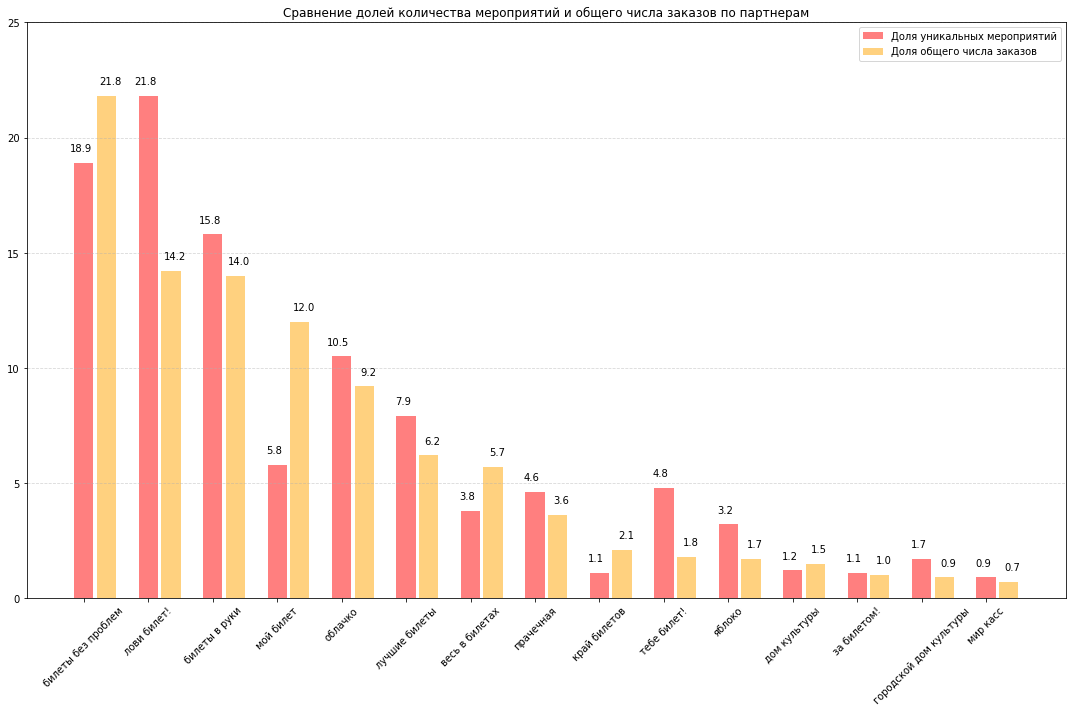

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Предполагаем, что event_partner уже содержит необходимые данные
plt.figure(figsize=(15, 10))

plt.ylim(0, 25)


# Создаём массив позиций для столбцов
x_positions_A = np.arange(len(event_partner['service_name']))
x_positions_B = x_positions_A + 0.35  # Сдвигаем позиции для второй группы

plt.bar(x_positions_A, event_partner['unique_events_share'], color='red', label='Доля уникальных мероприятий', alpha=0.5, width=0.3)
plt.bar(x_positions_B, event_partner['total_orders_share'], color='orange', label='Доля общего числа заказов', alpha=0.5, width=0.3)

plt.title('Сравнение долей количества мероприятий и общего числа заказов по партнерам')
plt.xlabel('')
plt.ylabel('')
plt.xticks(x_positions_A, event_partner['service_name'], rotation=45)  # Поворот названий сервисов для лучшего отображения
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Добавляем значения на столбцы
for i, (a_val, b_val) in enumerate(zip(event_partner['unique_events_share'], event_partner['total_orders_share'])):
    plt.text(i - 0.05, a_val + 0.5 , f'{a_val:.1f}', ha='center')
    plt.text(i + 0.41, b_val + 0.5 , f'{b_val:.1f}', ha='center')

plt.tight_layout()
plt.show()


**Анализ рынка показывает, что основная доля заказов приходится на несколько парнеров**
  - `Билеты без проблем`, 
  - `Мой билет`, 
  - `Облачко`, 
  - `Лови билет!`, 
  - `Весь в билетах` 
  - `Билеты в руки`
  - `Прачечная`

Парнеры имеет чётко выраженных лидеров: `Билеты без проблем`, `Лови билет!` с наибольшим количеством заказов и предлагаемых мероприятий, при этом разрыв между ними минимален, что говорит о равномерном распределении спроса между крупными билетными платформами. Это подтверждает высокую конкуренцию и сбалансированность рынка.

## Статистический анализ данных

Проврим две гипотезы, которые предполагают большую активность пользователей мобильных устройств:
- **Гипотеза №1**. Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств за осенний период.
- **Гипотеза №2**.Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств за осенний период.

Перед проведением гипотез:
- изучим сравниваемые данные, 
- обоснуем выбор статистического теста, 
- укажим формулировку нулевой и альтернативной гипотез.


### Гипотеза №1

**Сформулируем нулевую и альтернативную гипотезы проверки гипотезы №1:**

Нулевая гипотеза H₀: 
- Среднее количество заказов на одного пользователя одинаково для мобильных и стационарных устройств в осенний период.

Альтернативная гипотеза H₁: 
- Среднее количество заказов на одного пользователя выше у мобильных устройств, чем у стационарных устройств в осенний период.

In [58]:
# вновь отфильтруем данные за осенний период
df_autumn = df_all[df_all['season'] == 'осень'].copy()

In [59]:
# Группируем по типу устройства и пользователю, считаем количество заказов
user_orders = df_autumn.groupby(['user_id', 'device_type_canonical'])['order_id'].count().reset_index()

In [60]:
# Разделяем на две выборки
а_group_mobile = user_orders[user_orders['device_type_canonical'] == 'mobile']['order_id']
b_group_desktop = user_orders[user_orders['device_type_canonical'] == 'desktop']['order_id']

In [61]:
# Проверим статистику полученных групп
display(pd.DataFrame({'а_group_mobile': а_group_mobile,'b_group_desktop': b_group_desktop}).describe())

,а_group_mobile,b_group_desktop
count,14184.000000,4868.000000
mean,9.455795,7.043344
std,67.976420,35.966556
min,1.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,2.000000
75%,5.000000,4.000000
max,4327.000000,1501.000000


Характеристики выборок:
- Считаем выборки независимы, хотя одни и те же пользователи могу использовать мобильную и декстопную версии, но их поведение в разных версиях может отличаться. 
- Выборки существенно различаются по размеру (14 184 и 4868 наблюдений)
- Имеют неодинаковые дисперсии (стандартное отклонение 67.98 и 35.97), 
- Имеются существенные выбросы в данных
- Количество данных можно считать достаточным для применения Центральной предельной теоремы (ЦПТ), что  позволяет использовать методы статистического анализа, основанные на нормальном распределении.

Вывод: для проверки гипотезы целесообразно использовать t-тест Уэлча

t-тест Уэлча применяется для сравнения средних значений двух независимых выборок, когда предполагается, что их дисперсии не равны. Этот тест является альтернативой классическому t-тесту Стьюдента и используется в ситуациях, когда нарушается предположение о равенстве дисперсий.

Выберем стандартный уровень статистической значимости α = 0.05.

In [62]:
alpha = 0.05

# Проведение t-теста
result, p_value = ttest_ind(а_group_mobile, 
                            b_group_desktop,
                            equal_var=False,
                            alternative='greater')

print(f'p-value: {p_value}')
if p_value > alpha:
    print("Нулевую гипотезу не отвергаем: нет оснований говорить о том, что есть значимое различие в количестве заказов у пользователей в зависимости от устройства")
else:
    print("Принимаем альтернативную гипотезу.")


p-value: 0.0008557604121490505
Принимаем альтернативную гипотезу.


Результаты теста показали, что различие в среднем количестве заказов между пользователями мобильных и стационарных устройств статистически значимо. Это позволяет отвергнуть нулевую гипотезу и считать, что пользователи мобильных устройств совершают в среднем больше заказов, чем пользователи стационарных устройств.

### Гипотеза №2

Нулевая гипотеза (H₀): 
- среднее время между заказами пользователей мобильных приложений не выше по сравнению с пользователями стационарных устройств.

Альтернативная гипотеза (H₁): 
- среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

In [63]:
# Удалим пропуски
df2 = df_autumn.dropna(subset = ['days_since_prev'])

In [64]:
# Разделяем на две выборки
a_group_mobile = df2[df2['device_type_canonical'] == 'mobile']['days_since_prev']
b_group_desktop = df2[df2['device_type_canonical'] == 'desktop']['days_since_prev']

In [65]:
# Проверим статистику полученных групп
desc_mobile = a_group_mobile.describe()
desc_desktop = b_group_desktop.describe()

combined_desc = pd.concat([desc_mobile, desc_desktop], axis=1)

display(combined_desc)

,days_since_prev,days_since_prev
count,127140.000000,32929.000000
mean,3.780636,3.026633
std,13.387070,12.098106
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,1.000000
max,148.000000,146.000000


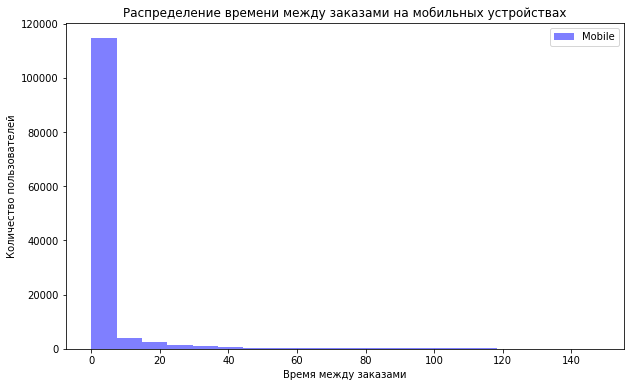

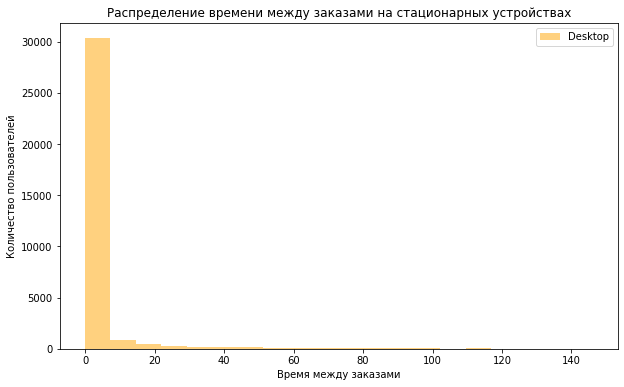

In [66]:
# Первый график для мобильных устройств
plt.figure(figsize=(10, 6))
plt.hist(a_group_mobile, bins=20, alpha=0.5, color='blue', label='Mobile')
plt.title('Распределение времени между заказами на мобильных устройствах')
plt.xlabel('Время между заказами')
plt.ylabel('Количество пользователей')
plt.legend()
plt.show()

# Второй график для стационарных устройств
plt.figure(figsize=(10, 6))
plt.hist(b_group_desktop, bins=20, alpha=0.5, color='orange', label='Desktop')
plt.title('Распределение времени между заказами на стационарных устройствах')
plt.xlabel('Время между заказами')
plt.ylabel('Количество пользователей')
plt.legend()
plt.show()


Характеристики выборок:
- Данные по времени между заказами имеют сильную асимметрию, множество нулей и выбросов (до 148 дней).
- Разница в средних: 3,7 для mobile против 3.0 desktop.
- Высокое стандартные отклонение: 13 для mobile и 12 для desktop, что указывает на высокую вариативность данных.
- Если взять 50 процентиль данных, то для desktop и для mobile это 0. Большая часть заказов совершается в тот же день (например, несколько заказов за один день, либо это может свидетельствовать об ошибке в данных).

Использование параметрических тестов некорректно. Больше подходит непараметрический тест Манна–Уитни, который сравнивает распределения двух независимых выборок.

Выберем стандартный уровень статистической значимости α = 0.05.

In [67]:
alpha = 0.05
stat, p_value = mannwhitneyu(desc_mobile, 
                            desc_desktop,
                            alternative='greater')
print(f'p-value: {p_value:}') 
if p_value > alpha:
    print("Нулевую гипотезу не отвергаем: нет оснований утверждать, что есть значимое различие в среднем времени между заказами пользователей в мобильном приложении по сравнению с пользователями стационарных устройств.")
else:
    print("Принимаем альтернативную гипотезу.")


p-value: 0.4357022661118589
Нулевую гипотезу не отвергаем: нет оснований утверждать, что есть значимое различие в среднем времени между заказами пользователей в мобильном приложении по сравнению с пользователями стационарных устройств.


Результаты теста показали, нельзя утверждать, что есть значимое различие в среднем времени между заказами пользователей в мобильном приложении по сравнению с пользователями стационарных устройств.
Для проверки гипотез был выбран тест Манна-Уитни, поскольку он подходит для тестирования групп разных размеров выборок, и при этом не чувствителен к выбросам и высокому среднему отклонению.

## Общий вывод и рекомендации

- В рамках проекта были проанализированы данные из трёх датасетов: final_tickets_orders_df.csv, final_tickets_events_df.csv и final_tickets_tenge_df.csv. После их объединения получился датафрейм с 24 столбцами и 290 849 строками, содержащий информацию о бронировании билетов на сервисе Яндекс Афиша с 1 июня по 30 октября 2024 года. Данные включали сведения о заказах билетов, событиях, городах и регионах проведения мероприятий, а также о курсе тенге к российскому рублю за 2024 год.
- В процессе первичной обработки данных выявлено, пропуски  были только в столбце days_since_prev. В других данных пропуски отсутствовали. 
- Было выполнено понижение размерности для числовых данных, в четырёх столбцах текстовых данные были  приведены к нижнему регистру. 
- По столбцу revenue проведена фильтрация до 99-го перцентиля для исключения выбросов при сохранении репрезентативности. 
- Удалено 30 неявных дубликатов. 
- Созданы новые столбцы: revenue_rub (выручка с заказа в российских рублях), one_ticket_revenue_rub (выручка с продажи одного билета), month (месяц оформления заказа), season (сезон). 
- После объединения татасетов, удаления выбросов и дубликатов итоговый объём составил 287 343  строки.
- Анализ данных показал, что наиболее популярными мероприятиями в оба сезона являются концерты, «другое» и театры. 
- Осенью наблюдается снижение заказов на концертов, рост спроса на театры и спорт, стабильно низкий спрос на выставки, стендап и ёлки. 
- Осенью количество заказов в 2 раза превышает летние показатели, с пиками в начале сентября и октября. 
- Средний чек осенью снижается по всем типам мероприятий, кроме выставок и стендапа, которые демонстрируют незначительный рост. 
- Активность пользователей осенью возрастает, в среднем на человека приходится 2–3 билета. 
- Среди регионов лидерами по числу заказов и выручке являются Каменевский регион, Североярская область, 
- Парнеры имеет чётко выраженных лидеров: Билеты без проблем, Лови билет! с наибольшим количеством заказов и предлагаемых мероприятий, при этом разрыв между ними минимален, что говорит о равномерном распределении спроса между крупными билетными платформами. 

**Выводы:**
Устойчивый рост выручки и заказов в сентябре–октябре.
Доминирование концертов и театров — стабильные драйверы дохода.
Высокая активность на мобильных устройствах — удобный канал продаж.
Резкие колебания среднего чека и выручки в конце периода.
Низкая активность в отдельных регионах.
Зависимость от немногих категорий мероприятий.

**Резултаты теста №1:**
различие в среднем количестве заказов между пользователями мобильных и стационарных устройств статистически значимо. Это позволяет считать, что пользователи мобильных устройств совершают в среднем больше заказов, чем пользователи стационарных устройств.

Для проверки гипотезы и сравнения средних значений двух выборок, при разных дисперсиях, был выбран t-тест Уэлча.

**Резултаты теста №2:** 
нельзя утверждать, что есть значимое различие в среднем времени между заказами пользователей в мобильном приложении по сравнению с пользователями стационарных устройств. 

Для проверки гипотез был выбран тест Манна-Уитни, поскольку он подходит для тестирования групп разных размеров выборок, и при этом не чувствителен к выбросам и высокому среднему отклонению.

**Рекомендации:**
Развивать высокомаржинальных направлений: концерты, фестивали.
Продолжить развивать канал продаж через мобильные устрайства.
Стимулировать спроса в низкоактивных регионах.